In [ ]:
#hii

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

files = [
    'application_train.csv',
    'application_test.csv',
    'bureau.csv',
    'bureau_balance.csv',
    'credit_card_balance.csv',
    'installments_payments.csv',
    'POS_CASH_balance.csv',
    'previous_application.csv',
]

# Base path
base_path = '/content/drive/MyDrive/home-credit-default-risk/'

for file in files:
    df = pd.read_csv(base_path + file)
    print(f"{file}: {df.shape}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
application_train.csv: (307511, 122)
application_test.csv: (48744, 121)
bureau.csv: (1716428, 17)
bureau_balance.csv: (27299925, 3)
credit_card_balance.csv: (3840312, 23)
installments_payments.csv: (13605401, 8)
POS_CASH_balance.csv: (10001358, 8)
previous_application.csv: (1670214, 37)


In [ ]:
import pandas as pd

train = pd.read_csv('/content/drive/MyDrive/home-credit-default-risk/application_train.csv')

# Shape of training data
print("Shape of training data:", train.shape)

# Value counts of TARGET (0 = non-default, 1 = default)
print("\nTARGET distribution:")
print(train['TARGET'].value_counts())
print("\nTARGET distribution (percent):")
print(train['TARGET'].value_counts(normalize=True) * 100)


Shape of training data: (307511, 122)

TARGET distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET distribution (percent):
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [ ]:
# Check general info
train.info()

# Check missing values
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nTop 20 columns with missing values:")
print(missing.head(20))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB

Top 20 columns with missing values:
COMMONAREA_MEDI             214865
COMMONAREA_MODE             214865
COMMONAREA_AVG              214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MEDI              208642
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
dtype: int64


In [ ]:
def clean_application_train_strategically(train):
    print("Cleaning application train strategically...")

    train_clean = train.copy()

    # External sources median
    for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
        train_clean[col] = train_clean[col].fillna(train_clean[col].median())

    # Car age 0 for no car
    train_clean['OWN_CAR_AGE'] = train_clean['OWN_CAR_AGE'].fillna(0)

    # Building information  median
    building_cols = [col for col in train_clean.columns if any(x in col for x in ['APARTMENTS', 'ELEVATORS', 'ENTRANCES', 'FLOORS', 'LIVING'])]
    for col in building_cols:
        if train_clean[col].dtype in ['int64', 'float64']:
            train_clean[col] = train_clean[col].fillna(train_clean[col].median())

    # Document flags 0 for missing (
    doc_cols = [col for col in train_clean.columns if 'FLAG_DOCUMENT' in col]
    for col in doc_cols:
        train_clean[col] = train_clean[col].fillna(0)

    # Credit bureau requests 0 for no requests
    bureau_req_cols = [col for col in train_clean.columns if 'AMT_REQ_CREDIT_BUREAU' in col]
    for col in bureau_req_cols:
        train_clean[col] = train_clean[col].fillna(0)

    # Social circle median for counts
    social_cols = [col for col in train_clean.columns if 'CNT_SOCIAL_CIRCLE' in col]
    for col in social_cols:
        train_clean[col] = train_clean[col].fillna(train_clean[col].median())

    # Categorical variables mode
    cat_cols = train_clean.select_dtypes(include='object').columns
    for col in cat_cols:
        mode_val = train_clean[col].mode()
        if not mode_val.empty:
            train_clean[col] = train_clean[col].fillna(mode_val[0])
        else:
            train_clean[col] = train_clean[col].fillna('Unknown')

    print(f"Application train cleaned: {train_clean.shape}")
    return train_clean

train_strategic = clean_application_train_strategically(train_cleaned)


NameError: name 'train_cleaned' is not defined

In [ ]:
import pandas as pd

df_merged_cleaned = train.copy()

# Drop columns with >70% missing data
col_threshold = 0.7
col_missing_ratio = df_merged_cleaned.isnull().mean()
cols_to_drop = col_missing_ratio[col_missing_ratio > col_threshold].index
df_merged_cleaned.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} columns with >70% missing.")

# Drop rows with >70% missing data
row_threshold = 0.7
row_missing_ratio = df_merged_cleaned.isnull().mean(axis=1)
rows_to_drop = row_missing_ratio[row_missing_ratio > row_threshold].index
df_merged_cleaned.drop(index=rows_to_drop, inplace=True)
print(f"Dropped {len(rows_to_drop)} rows with >70% missing.")

# Fill remaining missing values
for col in df_merged_cleaned.columns:
    if pd.api.types.is_numeric_dtype(df_merged_cleaned[col]):
        median_val = df_merged_cleaned[col].median()
        df_merged_cleaned[col].fillna(median_val, inplace=True)
    else:
        mode_val = df_merged_cleaned[col].mode(dropna=True)
        if not mode_val.empty:
            df_merged_cleaned[col].fillna(mode_val[0], inplace=True)
        else:
            df_merged_cleaned[col].fillna("Other", inplace=True)

# Copy back to df_merged
train_cleaned = df_merged_cleaned.copy()

print(f"Final cleaned DataFrame shape: {train_cleaned.shape}")


Dropped 0 columns with >70% missing.
Dropped 0 rows with >70% missing.


<ipython-input-11-3edd9cfd69c8>:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged_cleaned[col].fillna(median_val, inplace=True)
<ipython-input-11-3edd9cfd69c8>:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

Final cleaned DataFrame shape: (307511, 122)


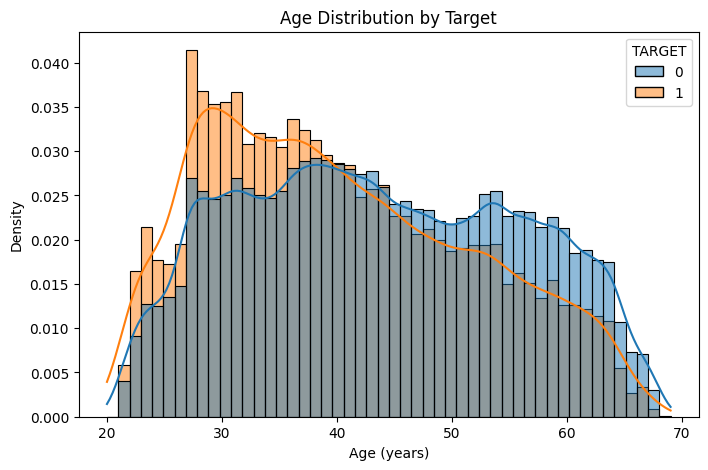

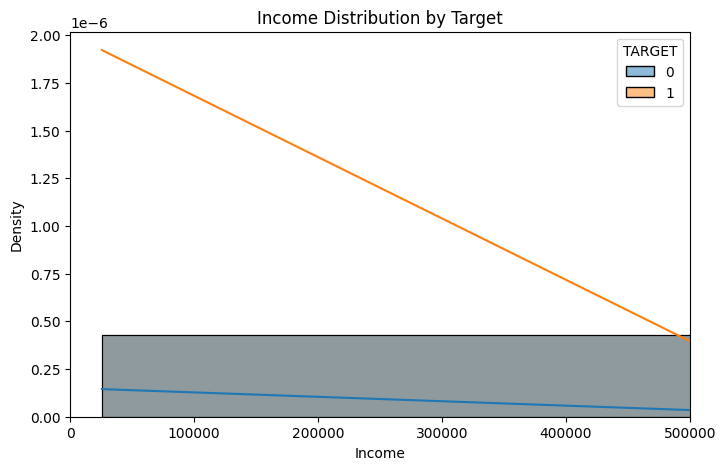

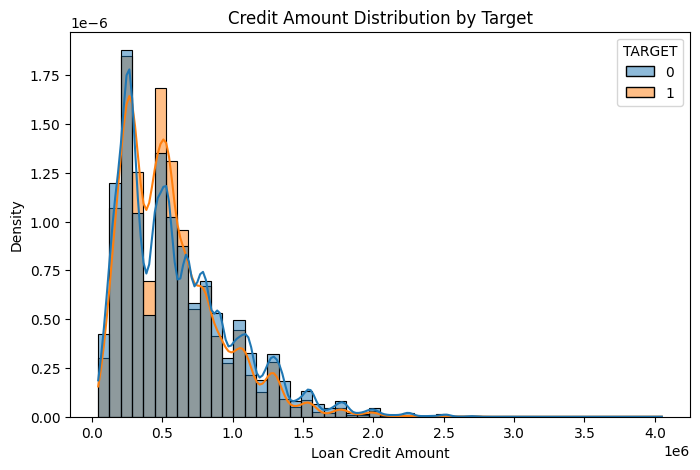

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert DAYS_BIRTH to positive age in years
train_cleaned['AGE'] = (-train_cleaned['DAYS_BIRTH']) // 365

# Plot AGE vs TARGET
plt.figure(figsize=(8, 5))
sns.histplot(data=train_cleaned, x='AGE', hue='TARGET', bins=50, kde=True, stat="density", common_norm=False)
plt.title('Age Distribution by Target')
plt.xlabel('Age (years)')
plt.show()

# Plot INCOME vs TARGET
plt.figure(figsize=(8, 5))
sns.histplot(data=train_cleaned, x='AMT_INCOME_TOTAL', hue='TARGET', bins=50, kde=True, stat="density", common_norm=False)
plt.title('Income Distribution by Target')
plt.xlabel('Income')
plt.xlim(0, 500000)
plt.show()

# Plot CREDIT amount vs TARGET
plt.figure(figsize=(8, 5))
sns.histplot(data=train_cleaned, x='AMT_CREDIT', hue='TARGET', bins=50, kde=True, stat="density", common_norm=False)
plt.title('Credit Amount Distribution by Target')
plt.xlabel('Loan Credit Amount')
plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder

df = train_cleaned.copy()

cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    if df[col].nunique() == 2:
        df[col] = le.fit_transform(df[col])
        print(f"Label encoded: {col}")

df = pd.get_dummies(df, columns=[col for col in cat_cols if df[col].dtype == 'object'], drop_first=True)

print("Final shape after encoding:", df.shape)


Categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
Label encoded: NAME_CONTRACT_TYPE
Label encoded: FLAG_OWN_CAR
Label encoded: FLAG_OWN_REALTY
Label encoded: EMERGENCYSTATE_MODE
Final shape after encoding: (307511, 231)


In [ ]:
# Load bureau data
bureau = pd.read_csv('/content/drive/MyDrive/home-credit-default-risk/bureau.csv')

# Show basic info
print("Shape of bureau:", bureau.shape)
print("Columns:", bureau.columns.tolist())
print("Sample rows:")
print(bureau.head())

print("\nUnique customers (SK_ID_CURR) in bureau:", bureau['SK_ID_CURR'].nunique())


Shape of bureau: (1716428, 17)
Columns: ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']
Sample rows:
   SK_ID_CURR  SK_ID_BUREAU CREDIT_ACTIVE CREDIT_CURRENCY  DAYS_CREDIT  \
0      215354       5714462        Closed      currency 1         -497   
1      215354       5714463        Active      currency 1         -208   
2      215354       5714464        Active      currency 1         -203   
3      215354       5714465        Active      currency 1         -203   
4      215354       5714466        Active      currency 1         -629   

   CREDIT_DAY_OVERDUE  DAYS_CREDIT_ENDDATE  DAYS_ENDDATE_FACT  \
0                   0               -153.0             -153.0   
1                   0            

In [ ]:
import pandas as pd

df_merged_cleaned = bureau.copy()

# Drop columns with >70% missing data
col_threshold = 0.7
col_missing_ratio = df_merged_cleaned.isnull().mean()
cols_to_drop = col_missing_ratio[col_missing_ratio > col_threshold].index
df_merged_cleaned.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} columns with >70% missing.")

# Drop rows with >70% missing data
row_threshold = 0.7
row_missing_ratio = df_merged_cleaned.isnull().mean(axis=1)
rows_to_drop = row_missing_ratio[row_missing_ratio > row_threshold].index
df_merged_cleaned.drop(index=rows_to_drop, inplace=True)
print(f"Dropped {len(rows_to_drop)} rows with >70% missing.")

# Fill remaining missing values
for col in df_merged_cleaned.columns:
    if pd.api.types.is_numeric_dtype(df_merged_cleaned[col]):
        median_val = df_merged_cleaned[col].median()
        df_merged_cleaned[col].fillna(median_val, inplace=True)
    else:
        mode_val = df_merged_cleaned[col].mode(dropna=True)
        if not mode_val.empty:
            df_merged_cleaned[col].fillna(mode_val[0], inplace=True)
        else:
            df_merged_cleaned[col].fillna("Other", inplace=True)

bureau = df_merged_cleaned.copy()

print(f"Final cleaned DataFrame shape: {bureau .shape}")


Dropped 1 columns with >70% missing.
Dropped 0 rows with >70% missing.


<ipython-input-15-284a91cd7cfd>:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged_cleaned[col].fillna(median_val, inplace=True)
<ipython-input-15-284a91cd7cfd>:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

Final cleaned DataFrame shape: (1716428, 16)


In [ ]:
# Separate numeric and categorical columns
bureau_num = bureau.select_dtypes(include=['int64', 'float64']).copy()
bureau_cat = bureau.select_dtypes(include='object').copy()

# Aggregate numeric features by mean, min, max, sum
bureau_num_agg = bureau_num.groupby('SK_ID_CURR').agg(['mean', 'min', 'max', 'sum'])
bureau_num_agg.columns = ['BUREAU_' + '_'.join(col).upper() for col in bureau_num_agg.columns]
bureau_num_agg.reset_index(inplace=True)

# One-hot encode categorical features, then aggregate by mean
bureau_cat = pd.get_dummies(bureau_cat)
bureau_cat['SK_ID_CURR'] = bureau['SK_ID_CURR']
bureau_cat_agg = bureau_cat.groupby('SK_ID_CURR').mean().reset_index()

# Merge numeric + categorical bureau features
bureau_agg = bureau_num_agg.merge(bureau_cat_agg, on='SK_ID_CURR', how='left')

print("Final shape of aggregated bureau:", bureau_agg.shape)


Final shape of aggregated bureau: (305811, 72)


In [ ]:
# Merge aggregated bureau data with main df using SK_ID_CURR
df_merged = df.merge(bureau_agg, on='SK_ID_CURR', how='left')

print("Final merged dataset shape:", df_merged.shape)


Final merged dataset shape: (307511, 302)


In [ ]:
previous_app = pd.read_csv('/content/drive/MyDrive/home-credit-default-risk/previous_application.csv')

print("Shape of previous_application:", previous_app.shape)
print("Columns:", previous_app.columns.tolist())
print("Sample rows:")
print(previous_app.head())
print("\nUnique SK_ID_CURR in previous_application:", previous_app['SK_ID_CURR'].nunique())


Shape of previous_application: (1670214, 37)
Columns: ['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION', 'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_TYPE_SUITE', 'NAME_CLIENT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY', 'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL']
Sample rows:
   SK_ID_PREV  SK_ID_CURR NAME_CONTRACT_TYPE  AMT_ANNUITY  AMT_APPLICATION  \
0     2030495      271877     Consumer loans     1730.430        

In [ ]:
import pandas as pd

# Copy the original DataFrame
df_merged_cleaned =previous_app.copy()

#  Drop columns with >70% missing data
col_threshold = 0.7
col_missing_ratio = df_merged_cleaned.isnull().mean()
cols_to_drop = col_missing_ratio[col_missing_ratio > col_threshold].index
df_merged_cleaned.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} columns with >70% missing.")
# Drop rows with >70% missing data
row_threshold = 0.7
row_missing_ratio = df_merged_cleaned.isnull().mean(axis=1)
rows_to_drop = row_missing_ratio[row_missing_ratio > row_threshold].index
df_merged_cleaned.drop(index=rows_to_drop, inplace=True)
print(f"Dropped {len(rows_to_drop)} rows with >70% missing.")

# Fill remaining missing values
for col in df_merged_cleaned.columns:
    if pd.api.types.is_numeric_dtype(df_merged_cleaned[col]):
        median_val = df_merged_cleaned[col].median()
        df_merged_cleaned[col].fillna(median_val, inplace=True)
    else:
        mode_val = df_merged_cleaned[col].mode(dropna=True)
        if not mode_val.empty:
            df_merged_cleaned[col].fillna(mode_val[0], inplace=True)
        else:
            df_merged_cleaned[col].fillna("Other", inplace=True)

# Copy back to df_merged
previous_app = df_merged_cleaned.copy()

print(f"Final cleaned DataFrame shape: {bureau .shape}")

Dropped 2 columns with >70% missing.
Dropped 0 rows with >70% missing.


<ipython-input-19-0366a97123a3>:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged_cleaned[col].fillna(median_val, inplace=True)
<ipython-input-19-0366a97123a3>:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

Final cleaned DataFrame shape: (1716428, 16)


In [ ]:
# Separate numeric and categorical columns
prev_num = previous_app.select_dtypes(include=['int64', 'float64']).copy()
prev_cat = previous_app.select_dtypes(include='object').copy()

# Aggregate numeric columns by mean, min, max, sum
prev_num_agg = prev_num.groupby('SK_ID_CURR').agg(['mean', 'min', 'max', 'sum'])
prev_num_agg.columns = ['PREVAPP_' + '_'.join(col).upper() for col in prev_num_agg.columns]
prev_num_agg.reset_index(inplace=True)

# One-hot encode categorical columns
prev_cat = pd.get_dummies(prev_cat)
prev_cat['SK_ID_CURR'] = previous_app['SK_ID_CURR']
prev_cat_agg = prev_cat.groupby('SK_ID_CURR').mean().reset_index()

# Merge numeric and categorical aggregated features
prevapp_agg = prev_num_agg.merge(prev_cat_agg, on='SK_ID_CURR', how='left')

print("Shape of aggregated previous_application:", prevapp_agg.shape)


Shape of aggregated previous_application: (338857, 216)


In [ ]:
df_merged = df_merged.merge(prevapp_agg, on='SK_ID_CURR', how='left')
print("Shape after merging previous_application:", df_merged.shape)


Shape after merging previous_application: (307511, 517)


In [ ]:
pos_cash = pd.read_csv('/content/drive/MyDrive/home-credit-default-risk/POS_CASH_balance.csv')

print("Shape of POS_CASH_balance:", pos_cash.shape)
print("Columns:", pos_cash.columns.tolist())
print("Sample rows:")
print(pos_cash.head())
print("\nUnique SK_ID_CURR in POS_CASH_balance:", pos_cash['SK_ID_CURR'].nunique())


Shape of POS_CASH_balance: (10001358, 8)
Columns: ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']
Sample rows:
   SK_ID_PREV  SK_ID_CURR  MONTHS_BALANCE  CNT_INSTALMENT  \
0     1803195      182943             -31            48.0   
1     1715348      367990             -33            36.0   
2     1784872      397406             -32            12.0   
3     1903291      269225             -35            48.0   
4     2341044      334279             -35            36.0   

   CNT_INSTALMENT_FUTURE NAME_CONTRACT_STATUS  SK_DPD  SK_DPD_DEF  
0                   45.0               Active       0           0  
1                   35.0               Active       0           0  
2                    9.0               Active       0           0  
3                   42.0               Active       0           0  
4                   35.0               Active       0           0  

Unique SK_ID_CURR in PO

In [ ]:
import pandas as pd

#  Copy the original DataFrame
df_merged_cleaned = pos_cash.copy()

# Drop columns with >70% missing data
col_threshold = 0.7
col_missing_ratio = df_merged_cleaned.isnull().mean()
cols_to_drop = col_missing_ratio[col_missing_ratio > col_threshold].index
df_merged_cleaned.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} columns with >70% missing.")

# Drop rows with >70% missing data
row_threshold = 0.7
row_missing_ratio = df_merged_cleaned.isnull().mean(axis=1)
rows_to_drop = row_missing_ratio[row_missing_ratio > row_threshold].index
df_merged_cleaned.drop(index=rows_to_drop, inplace=True)
print(f"Dropped {len(rows_to_drop)} rows with >70% missing.")

# Fill remaining missing values
for col in df_merged_cleaned.columns:
    if pd.api.types.is_numeric_dtype(df_merged_cleaned[col]):
        median_val = df_merged_cleaned[col].median()
        df_merged_cleaned[col].fillna(median_val, inplace=True)
    else:
        mode_val = df_merged_cleaned[col].mode(dropna=True)
        if not mode_val.empty:
            df_merged_cleaned[col].fillna(mode_val[0], inplace=True)
        else:
            df_merged_cleaned[col].fillna("Other", inplace=True)

# Copy back to df_merged
pos_cash= df_merged_cleaned.copy()

print(f"Final cleaned DataFrame shape: {pos_cash.shape}")


Dropped 0 columns with >70% missing.
Dropped 0 rows with >70% missing.


<ipython-input-23-53df2a6bf058>:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged_cleaned[col].fillna(median_val, inplace=True)


Final cleaned DataFrame shape: (10001358, 8)


In [ ]:
# Split numeric & categorical columns
pos_num = pos_cash.select_dtypes(include=['int64', 'float64']).copy()
pos_cat = pos_cash.select_dtypes(include='object').copy()

# Aggregate numeric by mean, min, max, sum
pos_num_agg = pos_num.groupby('SK_ID_CURR').agg(['mean', 'min', 'max', 'sum'])
pos_num_agg.columns = ['POS_' + '_'.join(col).upper() for col in pos_num_agg.columns]
pos_num_agg.reset_index(inplace=True)

# One-hot encode categorical and aggregate by mean
pos_cat = pd.get_dummies(pos_cat)
pos_cat['SK_ID_CURR'] = pos_cash['SK_ID_CURR']
pos_cat_agg = pos_cat.groupby('SK_ID_CURR').mean().reset_index()

# Merge numeric + categorical aggregated features
pos_agg = pos_num_agg.merge(pos_cat_agg, on='SK_ID_CURR', how='left')

print("Shape of aggregated POS_CASH_balance:", pos_agg.shape)



Shape of aggregated POS_CASH_balance: (337252, 34)


In [ ]:
df_merged = df_merged.merge(pos_agg, on='SK_ID_CURR', how='left')
print("Shape after merging POS_CASH_balance:", df_merged.shape)


Shape after merging POS_CASH_balance: (307511, 550)


In [ ]:
credit_card = pd.read_csv('/content/drive/MyDrive/home-credit-default-risk/credit_card_balance.csv')

print("Shape of credit_card_balance:", credit_card.shape)
print("Columns:", credit_card.columns.tolist())
print("Sample rows:")
print(credit_card.head())
print("\nUnique SK_ID_CURR in credit_card_balance:", credit_card['SK_ID_CURR'].nunique())


Shape of credit_card_balance: (3840312, 23)
Columns: ['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD', 'SK_DPD_DEF']
Sample rows:
   SK_ID_PREV  SK_ID_CURR  MONTHS_BALANCE  AMT_BALANCE  \
0     2562384      378907              -6       56.970   
1     2582071      363914              -1    63975.555   
2     1740877      371185              -7    31815.225   
3     1389973      337855              -4   236572.110   
4     1891521      126868              -1   453919.455   

   AMT_CREDIT_LIMIT_ACTUAL  AMT_DRAWINGS_ATM_CURREN

In [ ]:
import pandas as pd

#  Copy the original DataFrame
df_merged_cleaned = credit_card.copy()

# Drop columns with >70% missing data
col_threshold = 0.7
col_missing_ratio = df_merged_cleaned.isnull().mean()
cols_to_drop = col_missing_ratio[col_missing_ratio > col_threshold].index
df_merged_cleaned.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} columns with >70% missing.")

# Drop rows with >70% missing data
row_threshold = 0.7
row_missing_ratio = df_merged_cleaned.isnull().mean(axis=1)
rows_to_drop = row_missing_ratio[row_missing_ratio > row_threshold].index
df_merged_cleaned.drop(index=rows_to_drop, inplace=True)
print(f"Dropped {len(rows_to_drop)} rows with >70% missing.")

#  Fill remaining missing values
for col in df_merged_cleaned.columns:
    if pd.api.types.is_numeric_dtype(df_merged_cleaned[col]):
        median_val = df_merged_cleaned[col].median()
        df_merged_cleaned[col].fillna(median_val, inplace=True)
    else:
        mode_val = df_merged_cleaned[col].mode(dropna=True)
        if not mode_val.empty:
            df_merged_cleaned[col].fillna(mode_val[0], inplace=True)
        else:
            df_merged_cleaned[col].fillna("Other", inplace=True)

#  Copy back to df_merged
credit_card= df_merged_cleaned.copy()

print(f"Final cleaned DataFrame shape: {credit_card.shape}")


Dropped 0 columns with >70% missing.
Dropped 0 rows with >70% missing.


<ipython-input-27-d0ea102c6788>:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged_cleaned[col].fillna(median_val, inplace=True)
<ipython-input-27-d0ea102c6788>:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

Final cleaned DataFrame shape: (3840312, 23)


In [ ]:
# Select categorical columns
credit_card_cat = credit_card[['SK_ID_CURR', 'NAME_CONTRACT_STATUS']].copy()

# One-hot encode the categorical column(s), excluding SK_ID_CURR
credit_card_cat_encoded = pd.get_dummies(credit_card_cat.drop(['SK_ID_CURR'], axis=1))

# Add SK_ID_CURR back for grouping/merging
credit_card_cat_encoded['SK_ID_CURR'] = credit_card_cat['SK_ID_CURR']


In [ ]:
credit_card_cat_agg = credit_card_cat_encoded.groupby('SK_ID_CURR').mean().reset_index()


In [ ]:
# Aggregate numeric columns (exclude SK_ID_CURR, SK_ID_PREV)
num_cols = credit_card.select_dtypes(include=['number']).columns.tolist()
num_cols.remove('SK_ID_CURR')
num_cols.remove('SK_ID_PREV')

agg_funcs = ['mean', 'sum', 'max', 'min', 'count']
credit_card_num_agg = credit_card.groupby('SK_ID_CURR')[num_cols].agg(agg_funcs)
credit_card_num_agg.columns = ['{}_{}'.format(col, func) for col, func in credit_card_num_agg.columns]
credit_card_num_agg.reset_index(inplace=True)

#Merge numeric and categorical aggregations
credit_card_agg = credit_card_num_agg.merge(credit_card_cat_agg, on='SK_ID_CURR', how='left')

# Merge aggregated credit card features into your main dataframe df_merged
df_merged = df_merged.merge(credit_card_agg, on='SK_ID_CURR', how='left')

print("Shape after merging credit_card_balance:", df_merged.shape)



Shape after merging credit_card_balance: (307511, 657)


In [ ]:
df_merged.to_csv('df_merged_cleaned.csv', index=False)
print(" File saved as df_merged_cleaned.csv")


 File saved as df_merged_cleaned.csv


In [ ]:
import pandas as pd

# Replace 'your_file.csv' with your actual CSV file path or name
df_merged = pd.read_csv('/content/drive/MyDrive/df_merged_cleaned.csv')

# Optional: View the first few rows
print(df_merged.shape)


(307511, 657)
